# 3单因素方差分析
一个复杂的事物，其中往往有许多因素互相制约又互相依存。在众多因素和繁多的数据中，想要更加*直观方便地了解各种因素对某变量的影响*，方差分析是一个不错的选择。<br/>
**什么是方差分析？** <br/>
方差分析(Analysis of Variance，简称ANOVA)，又称"变异数分析"或"F检验"，是R.A.Fisher发明的，用于两个及两个以上样本均数差别的显著性检验。由于各种因素的影响，研究所得的数据呈现波动状。造成波动的原因可分成两类，一是不可控的随机因素，另一是研究中施加的对结果形成影响的可控因素。<br/>
**方差有什么用？** <br/>
方差分析可以用来判断几组观察到的数据或者处理的结果是否存在显著差异。方差分析是从观测变量的方差入手，研究诸多控制变量中哪些变量是对观测变量有显著影响的变量。<br/>
单因素方差分析：是用来研究一个控制变量的不同水平是否对观测变量产生了显著影响，仅研究单个因素对观测变量的影响。<br/>
例如，分析不同施肥量是否给农作物产量带来显著影响，考察地区差异是否影响妇女的生育率，研究学历对工资收入的影响等。<br/>

**方差分析的基本原理**
$$总误差(SST)=组内误差(SSE)+组间误差(SSR)$$
若不同处理对总体无影响，则就是组内误差近似等于组间误差，或相差不大.若$\frac{SSR}{SSE}>1$到一定程度（显著）则可认为分类变量对总体有影响

方差分析的基本假定

1、每个总体都应服从正态分布

2、每个总体的方差$\sigma^2$必须相同

3、观测值是独立的


总变异（Total variation）：全部测量值xij与总均数间μ的差异

$$SST=\sum^m_{i=1}\sum^{n_i}_{j=1} (x_{ij}-\mu)^2$$

自由度 $$DT=N-1$$

组间变异（ between group variation ）：各组的均数μi与总均数μ间的差异

$$SSR=\sum^m_{i=1} n_i(\mu_i-\mu)^2$$

自由度 $$DB=m-1$$

组内变异（within groupvariation )：每组的每个测量值xij与该组均数μi的差异

$$SSE=\sum^m_{i=1}\sum^{n_i}_{j=1} (x_{ij}-\mu_i)^2$$

自由度 $$DW=\sum^m_{i=1} (n_i-1)$$

其中，m表示观察组的个数，$n_i$表示每一组的观察数，N表示总观察数

其中，三种变异的关系为：
$$SST = SSE + SSR$$
$$DT = DB+ DW$$

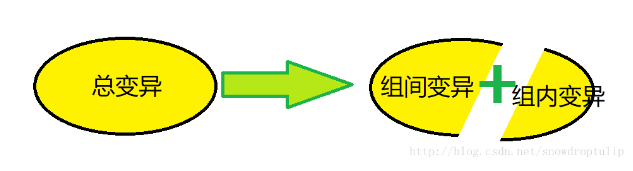


方差分析的LSD方法

第一步：提出原假设，即

$H_0:\mu_i=\mu_j$ 自变量对因变量没有显著影响

$H_1:\mu_i \not=\mu_j$自变量对因变量没有显著影响

第二步：计算检验统计量 $\bar x_i-\bar x_j$

第三步：计算LSD，$LSD=t_\frac{\alpha}{2}\sqrt{MSE(\frac{1}{n_i}+\frac{1}{n_j})}$

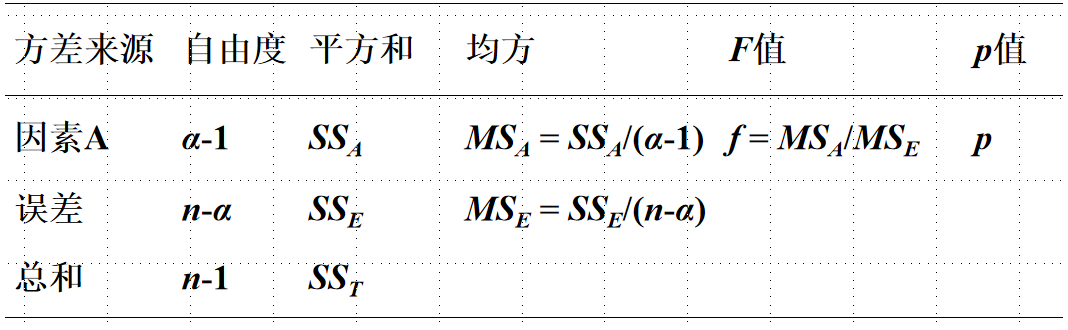

第四步：根据显著性水平$\alpha$做出决策<br/>
若$|\bar x_i-\bar x_j|>LSD$,则拒绝原假设$H_0$<br/>
若$|\bar x_i-\bar x_j|<LSD$,则不能拒绝原假设$H_0$

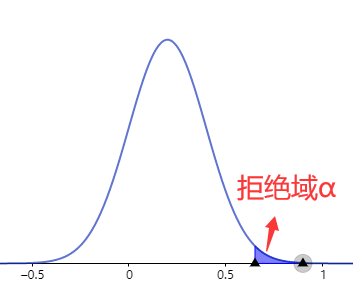


In [44]:
#有三组人，分别服用了不同的高血压药A，B，C一个月以后，观察每一个人血压下降数
# A组       4     5     7     3     8     5     3     μA= 5.00
# B组       1     5     3     7     4     2     7     4     1      μB= 3.78
# C组       7     8     10    6     9     8           μC= 8.00

# 假设：

# H0：A，B，C三个药下降血压效果没有区别，即μA= μB= μC

# H1：A，B，C三个药下降血压有区别

import numpy as np
A = [4,5,7,3,8,5,3]
B = [1,5,3,7,4,2,7,4,1]
C = [7,8,10,6,9,8]
miu_a = np.mean(A)
miu_b = np.mean(B)
miu_c = np.mean(C)
print('var',np.var(A),np.var(B),np.var(C))
M = A+B+C
print('miu',miu)
print(miu_a,miu_b,miu_c)
miu = np.sum(M)/22
#总误差平方和SST
SST = np.sum([(x-miu)**2 for x in M]) 
print('sst',SST)
#水平项误差平方和
SSR = np.sum([(miu_a-miu)**2 for x in range(len(A))])+np.sum([(miu_b-miu)**2 for x in range(len(B))])+np.sum([(miu_c-miu)**2 for x in range(len(C))])
# SSB = 3*(miu_a-miu)**2+3*(miu_b-miu)**2+3*(miu_c-miu)**2
print('SSB',SSR)
#误差项平方和
SSE = np.sum([(x-miu_a)**2 for x in A])+np.sum([(x-miu_b)**2 for x in B])+np.sum([(x-miu_c)**2 for x in C])
print('SSW',SSE)
#SST = SSW + SSR
print(SST-SSE)

#自由度DT DB DW
#我们知道样本总共有22个，而且我们知道样本总体的值，所以我们只需要知道其中21个样本，剩下的1个就可以的出来，所以总体自由度DT= 22-1 = 21
#因为我们有3组，我们只需要知道其中的两组，另外一组也可以的出来，所以组间自由度DB= 3-2 = 2
# 第一组有7个样本，我们只需要知道其中的6个，剩下的一个可以的出来，所以第一组的自由度DW1= (7-1) = 6，同理，第二三组的也可以的出来，所以总的组内自由度DW= (7-1) + (9-1) +(6-1) = 19
#同理，我们有性质DT = DB + DW，所以我们只要知道其中两个自由度，剩下的一个可以由公式得出。
#最后我们求F，F的公式为F = (SSB/DB) / (SSW/DW) =(65.2/2) / (73.6/19) = 8.42，且自由度为F(2,19)
DT = 22-1
DB = 3-1
DW = (7-1) + (9-1) + (6-1)
F = (SSR/DB) / (SSE/DW)
print('F',F)
#自由度F(DB,DW)

F,p = stats.f_oneway(A,B,C)
print('F=',F,'p=',p)

var 3.142857142857143 4.617283950617284 1.6666666666666667
miu 5.318181818181818
5.0 3.7777777777777777 8.0
sst 138.77272727272728
SSB 65.21717171717171
SSW 73.55555555555556
65.21717171717172
F 8.423063718758582
F= 8.42306371875858 p= 0.0024041296630908063


此时我们α=0.05的F分布表如下图，我们看到自由度为2和19时，置信度为95%的值为3.52，而此时我们的值为8.42，远超过3.52，所以我们接受H0的概率小于0.05，所以拒绝H0假设，接受H1，即A，B，C三个药的效果有明显的不同
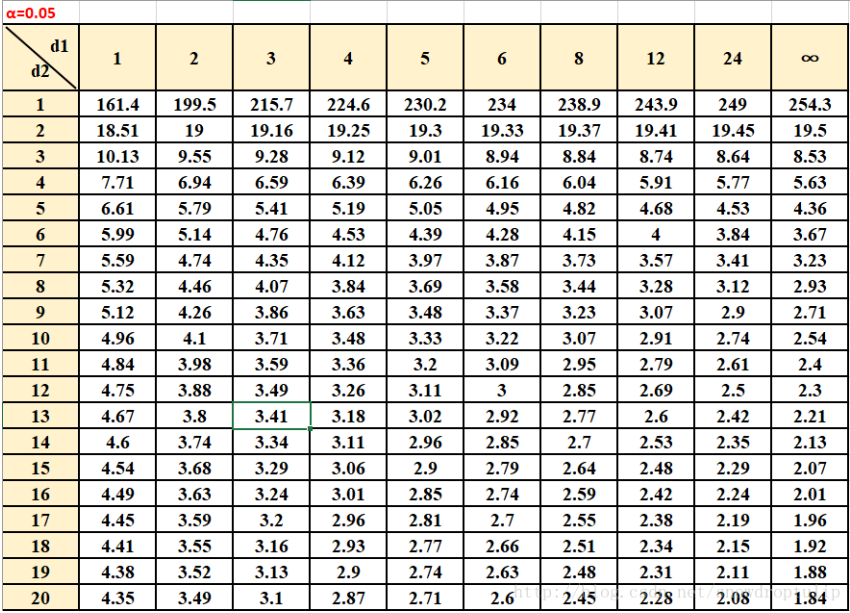

In [1]:
#P103,例3.1
import pandas as pd
import math
import numpy as np
from statsmodels.stats.anova import anova_lm
from scipy import stats

a=[164,190,203,205,206,214,228,257]
b=[185,197,201,231]
c=[187,212,215,220,248,265,281]
f,p = stats.f_oneway(a,b,c)
print(f)
print(p)

1.8698693922664025
0.1863067759191735


In [12]:
#来自五个地点的贻贝贻 Shell 测量(前内收肌疤痕的长度，通过除以长度标准化)：俄勒冈州蒂拉穆克；俄勒冈州纽波特；阿拉斯加州圣彼得堡；俄罗斯马加丹；和芬兰的 Tvarminne，
#取自 McDonald 等人使用的更大的数据集。
tillamook = [0.0571, 0.0813, 0.0831, 0.0976, 0.0817, 0.0859, 0.0735, 0.0659, 0.0923, 0.0836]
newport = [0.0873, 0.0662, 0.0672, 0.0819, 0.0749, 0.0649, 0.0835, 0.0725]
petersburg = [0.0974, 0.1352, 0.0817, 0.1016, 0.0968, 0.1064, 0.105]
magadan = [0.1033, 0.0915, 0.0781, 0.0685, 0.0677, 0.0697, 0.0764, 0.0689]
tvarminne = [0.0703, 0.1026, 0.0956, 0.0973, 0.1039, 0.1045]
statistic, pvalue = stats.f_oneway(tillamook, newport, petersburg, magadan, tvarminne)
print('statistic=',statistic,'pvalue=',pvalue)
# F_onewayResult(statistic=7.121019471642447, pvalue=0.0002812242314534544)

statistic= 7.121019471642447 pvalue= 0.0002812242314534544


In [16]:
# scipy.stats.f_oneway接受多维输入数组。当输入是多维的并且轴没有给出，测试是沿着输入数组的第一个轴执行的。对于以下数据，进行3次测试，每列一次。
a = np.array([[9.87, 9.03, 6.81],
              [7.18, 8.35, 7.00],
              [8.39, 7.58, 7.68],
               [7.45, 6.33, 9.35],
               [6.41, 7.10, 9.33],
               [8.00, 8.24, 8.44]])
b = np.array([[6.35, 7.30, 7.16],
               [6.65, 6.68, 7.63],
               [5.72, 7.73, 6.72],
               [7.01, 9.19, 7.41],
               [7.75, 7.87, 8.30],
               [6.90, 7.97, 6.97]])
c = np.array([[3.31, 8.77, 1.01],
               [8.25, 3.24, 3.62],
               [6.32, 8.81, 5.19],
               [7.48, 8.83, 8.91],
               [8.59, 6.01, 6.07],
               [3.07, 9.72, 7.48]])
F, p = stats.f_oneway(a, b, c)
# array([0.20630784, 0.96375203, 0.04733157])

array([0.20630784, 0.96375203, 0.04733157])